# **AI Advanced Ahmed Yousrey Course Practice**

---
# **DAY 8 — Video Activity Detector**
---

# **STEP 1 - IMPORT LIBRARIES**

---

In [55]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout

import warnings
warnings.filterwarnings("ignore")

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"


---
# **STEP 2 - IMPORT DATA**

---

In [56]:

print(os.listdir("/kaggle/input/datasets/daudshah/video-dataset/dataset-video-split"))

['valid.txt', 'test.txt', 'train.txt', 'valid', 'test', 'lable.txt', 'train']


In [57]:
import os

base_path = "/kaggle/input/datasets/daudshah/video-dataset/dataset-video-split"

print(os.listdir(os.path.join(base_path, "train"))[:20])

['Standing_Still_(77).mp4', 'RoadAccidents009_x264.mp4', 'RoadAccidents033_x264.mp4', 'Arrest015_x264.mp4', 'Robbery008_x264.mp4', 'RoadAccidents006_x264.mp4', 'Shooting047_x264.mp4', 'Walking_While_Reading_Book_(60).mp4', 'Shooting046_x264.mp4', 'Clapping_(108).mp4', 'Stealing093_x264.mp4', 'Stealing092_x264.mp4', 'Burglary010_x264.mp4', 'Sitting_(79).mp4', 'Shooting009_x264.mp4', 'Shoplifting055_x264.mp4', 'Shoplifting045_x264.mp4', 'Abuse022_x264.mp4', 'Walking_While_Reading_Book_(73).mp4', 'Standing_Still_(90).mp4']


---
# **STEP 3 - EDA**

---

explore the labels of the data

In [58]:
label_path = os.path.join(base_path, "lable.txt")

with open(label_path, "r") as f:
    print(f.read())

Vandalism 0  
Stealing 1  
Shoplifting 2  
Shooting 3  
Robbery 4  
Roadaccidents 5  
Normal 6  
Walking 7  
Walking_While_Using_Phone 8  
Walking_While_Reading_Book 9  
Standing_Still 10  
Sitting 11  
Fighting 12  
Explosion 13  
Meet_and_Split 14  
Burglary 15  
Clapping 16  
Assault 17  
Arson 18  
Arrest 19  
Abuse 20  


In [59]:
train_txt = os.path.join(base_path, "train.txt")

with open(train_txt, "r") as f:
    for _ in range(20):
        print(f.readline().strip())

Abuse001_x264.mp4 20
Abuse002_x264.mp4 20
Abuse003_x264.mp4 20
Abuse004_x264.mp4 20
Abuse005_x264.mp4 20
Abuse006_x264.mp4 20
Abuse007_x264.mp4 20
Abuse008_x264.mp4 20
Abuse009_x264.mp4 20
Abuse010_x264.mp4 20
Abuse011_x264.mp4 20
Abuse012_x264.mp4 20
Abuse013_x264.mp4 20
Abuse015_x264.mp4 20
Abuse016_x264.mp4 20
Abuse017_x264.mp4 20
Abuse019_x264.mp4 20
Abuse021_x264.mp4 20
Abuse022_x264.mp4 20
Abuse023_x264.mp4 20


find the number of videos in every split

In [60]:
for split in ["train", "valid", "test"]:
    split_path = os.path.join(base_path, split)

    videos = [
        f for f in os.listdir(split_path)
        if f.endswith(".mp4")
    ]

    print(split, len(videos))

train 940
valid 194
test 200


In [61]:
from collections import Counter

def load_labels(txt_path):
    labels = []

    with open(txt_path, "r") as f:
        for line in f:
            filename, label = line.strip().split()
            labels.append(int(label))

    return labels


train_labels = load_labels(os.path.join(base_path, "train.txt"))
valid_labels = load_labels(os.path.join(base_path, "valid.txt"))
test_labels = load_labels(os.path.join(base_path, "test.txt"))


train_counts = Counter(train_labels)
valid_counts = Counter(valid_labels)
test_counts = Counter(test_labels)


print("Train:", len(train_labels))
print("Valid:", len(valid_labels))
print("Test:", len(test_labels))

print("\nTrain distribution:")
print(train_counts)

print("\nValidation distribution:")
print(valid_counts)

print("\nTest distribution:")
print(test_counts)

Train: 940
Valid: 194
Test: 200

Train distribution:
Counter({6: 100, 1: 80, 20: 40, 19: 40, 18: 40, 17: 40, 15: 40, 16: 40, 13: 40, 12: 40, 14: 40, 5: 40, 4: 40, 3: 40, 2: 40, 11: 40, 10: 40, 0: 40, 7: 40, 9: 40, 8: 40})

Validation distribution:
Counter({6: 20, 11: 11, 15: 10, 16: 10, 14: 10, 5: 10, 4: 10, 10: 10, 1: 10, 7: 10, 9: 10, 8: 10, 20: 7, 19: 7, 18: 7, 17: 7, 13: 7, 12: 7, 3: 7, 2: 7, 0: 7})

Test distribution:
Counter({6: 66, 10: 12, 7: 12, 9: 12, 11: 11, 16: 10, 14: 10, 5: 10, 4: 10, 8: 10, 1: 7, 20: 3, 19: 3, 18: 3, 17: 3, 15: 3, 13: 3, 12: 3, 3: 3, 2: 3, 0: 3})


classes distribution

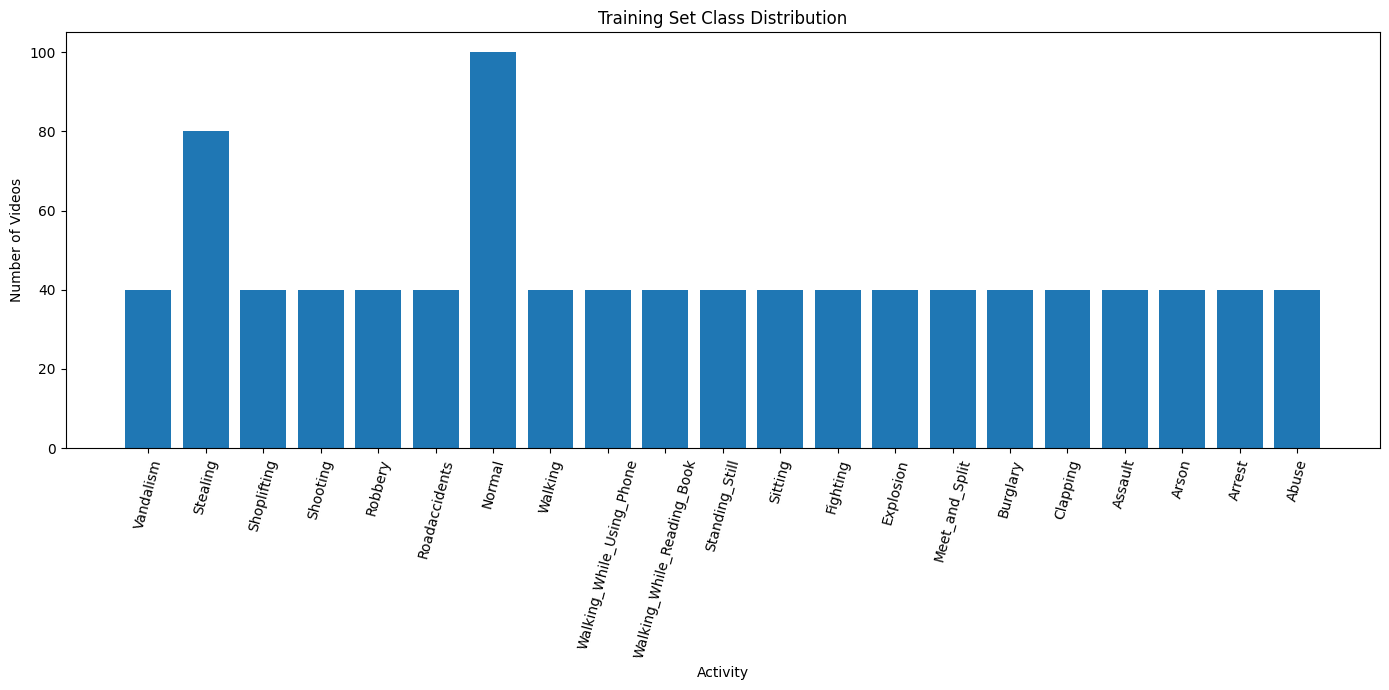

In [62]:
class_names = {
    0: "Vandalism",
    1: "Stealing",
    2: "Shoplifting",
    3: "Shooting",
    4: "Robbery",
    5: "Roadaccidents",
    6: "Normal",
    7: "Walking",
    8: "Walking_While_Using_Phone",
    9: "Walking_While_Reading_Book",
    10: "Standing_Still",
    11: "Sitting",
    12: "Fighting",
    13: "Explosion",
    14: "Meet_and_Split",
    15: "Burglary",
    16: "Clapping",
    17: "Assault",
    18: "Arson",
    19: "Arrest",
    20: "Abuse"
}

labels = list(class_names.keys())
names = [class_names[label] for label in labels]
counts = [train_counts[label] for label in labels]

plt.figure(figsize=(14, 7))

plt.bar(names, counts)

plt.xticks(rotation=75)
plt.xlabel("Activity")
plt.ylabel("Number of Videos")
plt.title("Training Set Class Distribution")

plt.tight_layout()
plt.show()

find the video_properties 

In [63]:
video_properties = []

train_path = os.path.join(base_path, "train")

for filename in os.listdir(train_path):

    if not filename.endswith(".mp4"):
        continue

    video_path = os.path.join(train_path, filename)

    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    cap.release()

    if fps > 0:
        duration = frame_count / fps
    else:
        duration = 0

    video_properties.append({
        "filename": filename,
        "fps": fps,
        "frame_count": frame_count,
        "width": width,
        "height": height,
        "duration": duration
    })

print("Videos analyzed:", len(video_properties))

Videos analyzed: 940


In [64]:
import pandas as pd

video_df = pd.DataFrame(video_properties)

video_df.head()

,filename,fps,frame_count,width,height,duration
0,Standing_Still_(77).mp4,30.0,317,1080,1920,10.566667
1,RoadAccidents009_x264.mp4,30.0,900,320,240,30.000000
2,RoadAccidents033_x264.mp4,30.0,587,320,240,19.566667
3,Arrest015_x264.mp4,30.0,900,320,240,30.000000
4,Robbery008_x264.mp4,30.0,900,320,240,30.000000


In [65]:
video_df[[
    "fps",
    "frame_count",
    "width",
    "height",
    "duration"
]].describe()

,fps,frame_count,width,height,duration
count,940.0,940.000000,940.000000,940.000000,940.000000
mean,30.0,692.498936,616.978723,669.829787,23.083298
std,0.0,274.389346,500.726862,691.786880,9.146312
min,30.0,120.000000,320.000000,240.000000,4.000000
25%,30.0,332.000000,320.000000,240.000000,11.066667
50%,30.0,900.000000,320.000000,240.000000,30.000000
75%,30.0,900.000000,1080.000000,1080.000000,30.000000
max,30.0,900.000000,1920.000000,1920.000000,30.000000


find the size and number os frames for every video

In [66]:
import cv2
import os

video_name = "Abuse001_x264.mp4"

video_path = os.path.join(base_path, "train", video_name)

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps

print("FPS:", fps)
print("Frame Count:", frame_count)
print("Width:", width)
print("Height:", height)
print("Duration:", duration, "seconds")

cap.release()

FPS: 30.0
Frame Count: 900
Width: 320
Height: 240
Duration: 30.0 seconds


---
# **STEP 4 - Preprocessing**

---

resize the frame size and count + normalization

In [161]:


NUM_FRAMES = 16
IMG_SIZE = (224, 224)

cap = cv2.VideoCapture(video_path)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

frame_indices = np.linspace(
    0,
    total_frames - 1,
    NUM_FRAMES,
    dtype=int
)

frames = []

for idx in frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)

    ret, frame = cap.read()

    if ret:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, IMG_SIZE)
        frame = frame / 255.0
        frames.append(frame)

cap.release()

frames = np.array(frames)

print("Frames shape:", frames.shape)
print("Min:", frames.min())
print("Max:", frames.max())

Frames shape: (16, 224, 224, 3)
Min: 0.0
Max: 1.0


show the video frames after resizing

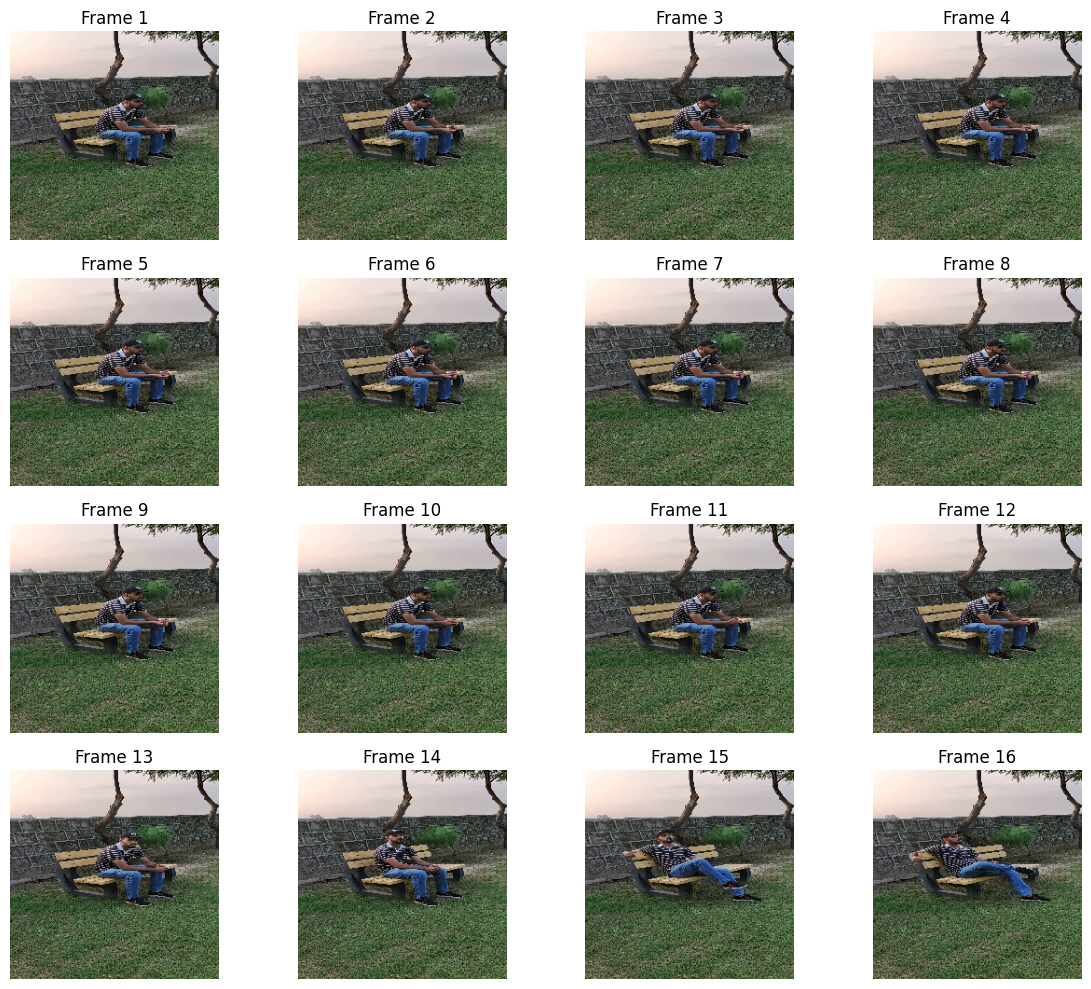

In [151]:
fig, axes = plt.subplots(4, 4, figsize=(12, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(frames[i])
    ax.set_title(f"Frame {i + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

test mobilenet on one frame

In [152]:

cnn = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

cnn.trainable = False

In [153]:
sample_frame = frames[0]

sample_frame = np.expand_dims(sample_frame, axis=0)

features = cnn.predict(sample_frame, verbose=0)

print("Input shape:", sample_frame.shape)
print("Feature shape:", features.shape)

Input shape: (1, 224, 224, 3)
Feature shape: (1, 1280)


test mobilenet on the 16 frame

In [154]:
sequence_features = cnn.predict(frames, verbose=0)

print("Frames shape:", frames.shape)
print("Features shape:", sequence_features.shape)

Frames shape: (16, 224, 224, 3)
Features shape: (16, 1280)


now we will create a pipeline do redo the last step of getting the right size of features but in all the dataset

In [155]:
def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        NUM_FRAMES,
        dtype=int
    )

    frames = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)

        ret, frame = cap.read()

        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, IMG_SIZE)
            frame = frame / 255.0
            frames.append(frame)

    cap.release()

    return np.array(frames)

In [156]:
def extract_features(video_path, cnn):
    frames = extract_frames(video_path)

    if len(frames) != NUM_FRAMES:
        return None

    features = cnn.predict(
        frames,
        verbose=0
    )

    return features

In [157]:
sample_video = os.path.join(
    train_path,
    "Abuse001_x264.mp4"
)

features = extract_features(sample_video, cnn)

print(features.shape)

(16, 1280)


create a loop to process the training videos and store the features.

In [166]:
BATCH_SIZE = 4

def process_video_batch(video_paths, labels, cnn):
    batch_frames = []
    
    for video_path in video_paths:
        frames = extract_frames(video_path)
        
        if len(frames) == NUM_FRAMES:
            batch_frames.append(frames)

    if not batch_frames:
        return None, None

    batch_frames = np.array(batch_frames)

    # (batch, 16, 224, 224, 3)
    batch_size = batch_frames.shape[0]

    # Combine all frames
    frames_flat = batch_frames.reshape(
        -1, 224, 224, 3
    )

    with tf.device("/GPU:0"):
        features_flat = cnn(frames_flat, training=False)

    # Back to video sequences
    features = features_flat.numpy().reshape(
        batch_size, NUM_FRAMES, 1280
    )

    return features, np.array(labels)

In [ ]:
X_train = []
y_train = []

train_paths = []
train_labels = []

with open(os.path.join(base_path, "train.txt"), "r") as f:
    for line in f:
        filename, label = line.strip().split()

        train_paths.append(os.path.join(train_path, filename))
        train_labels.append(int(label))

for i in range(0, len(train_paths), BATCH_SIZE):

    batch_paths = train_paths[i:i + BATCH_SIZE]
    batch_labels = train_labels[i:i + BATCH_SIZE]

    features, labels = process_video_batch(
        batch_paths,
        batch_labels,
        cnn
    )

    if features is not None:
        X_train.append(features)
        y_train.append(labels)

    if (i // BATCH_SIZE) % 10 == 0:
        print(f"Processed: {min(i + BATCH_SIZE, len(train_paths))}/{len(train_paths)}")

Processed: 4/940
Processed: 44/940
Processed: 84/940
Processed: 124/940
Processed: 164/940
Processed: 204/940
Processed: 244/940
Processed: 284/940
Processed: 324/940
Processed: 364/940
Processed: 404/940
Processed: 444/940
Processed: 484/940
Processed: 524/940
Processed: 564/940
Processed: 604/940
Processed: 644/940
Processed: 684/940
Processed: 724/940
Processed: 764/940
Processed: 804/940
Processed: 844/940
Processed: 884/940
Processed: 924/940


In [ ]:
X_train = np.concatenate(X_train, axis=0)
y_train = np.concatenate(y_train, axis=0)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

repeat the same steps with validation data

In [ ]:
valid_path = os.path.join(base_path, "valid")

valid_paths = []
valid_labels = []

with open(os.path.join(base_path, "valid.txt"), "r") as f:
    for line in f:
        filename, label = line.strip().split()

        valid_paths.append(
            os.path.join(valid_path, filename)
        )
        valid_labels.append(int(label))

print("Validation videos:", len(valid_paths))

In [89]:
X_valid = []
y_valid = []

for i in range(0, len(valid_paths), BATCH_SIZE):

    batch_paths = valid_paths[i:i + BATCH_SIZE]
    batch_labels = valid_labels[i:i + BATCH_SIZE]

    features, labels = process_video_batch(
        batch_paths,
        batch_labels,
        cnn
    )

    if features is not None:
        X_valid.append(features)
        y_valid.append(labels)

    if (i // BATCH_SIZE) % 5 == 0:
        print(
            f"Processed: "
            f"{min(i + BATCH_SIZE, len(valid_paths))}"
            f"/{len(valid_paths)}"
        )

Processed: 8/194
Processed: 48/194
Processed: 88/194
Processed: 128/194
Processed: 168/194


In [90]:
X_valid = np.concatenate(X_valid, axis=0)
y_valid = np.concatenate(y_valid, axis=0)

print("X_valid shape:", X_valid.shape)
print("y_valid shape:", y_valid.shape)

X_valid shape: (194, 16, 1280)
y_valid shape: (194,)


repeat the same steps with test data

In [91]:
test_path = os.path.join(base_path, "test")

test_paths = []
test_labels = []

with open(os.path.join(base_path, "test.txt"), "r") as f:
    for line in f:
        filename, label = line.strip().split()

        test_paths.append(
            os.path.join(test_path, filename)
        )
        test_labels.append(int(label))

print("Test videos:", len(test_paths))

Test videos: 200


In [92]:
X_test = []
y_test = []

for i in range(0, len(test_paths), BATCH_SIZE):

    batch_paths = test_paths[i:i + BATCH_SIZE]
    batch_labels = test_labels[i:i + BATCH_SIZE]

    features, labels = process_video_batch(
        batch_paths,
        batch_labels,
        cnn
    )

    if features is not None:
        X_test.append(features)
        y_test.append(labels)

    if (i // BATCH_SIZE) % 5 == 0:
        print(
            f"Processed: "
            f"{min(i + BATCH_SIZE, len(test_paths))}"
            f"/{len(test_paths)}"
        )

Processed: 8/200
Processed: 48/200
Processed: 88/200
Processed: 128/200
Processed: 168/200


In [93]:
X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (200, 16, 1280)
y_test shape: (200,)


---
# **STEP 5 - BUILT THE BiLSTM**

---

built the model

In [108]:
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Input(shape=(16, 1280)),

    layers.Bidirectional(
        layers.LSTM(128)
    ),

    layers.Dropout(0.5),

    layers.Dense(64, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(21, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 256)            │     1,442,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 21)             │         1,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,460,629 (5.57 MB)

 Trainable params: 1,460,629 (5.57 MB)

 Non-trainable params: 0 (0.00 B)

In [109]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [110]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=30,
    batch_size=16,
    callbacks=[early_stopping]
)

Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.1053 - loss: 3.0380 - val_accuracy: 0.2062 - val_loss: 2.8243
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1809 - loss: 2.7684 - val_accuracy: 0.2784 - val_loss: 2.4945
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2383 - loss: 2.5083 - val_accuracy: 0.3247 - val_loss: 2.1647
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2989 - loss: 2.2852 - val_accuracy: 0.3918 - val_loss: 2.0357
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3447 - loss: 2.1422 - val_accuracy: 0.4072 - val_loss: 1.9541
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3840 - loss: 1.9530 - val_accuracy: 0.3608 - val_loss: 1.9173
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4351 - loss: 1.8291 - val_accuracy: 0.4330 - val_loss: 1.8123
Epoch 8/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4372 - loss: 1.7564 - val_accuracy: 0.4278 - val_

evaluate the model

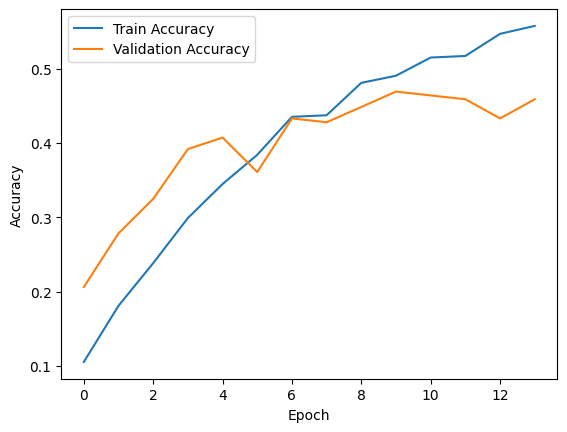

In [111]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

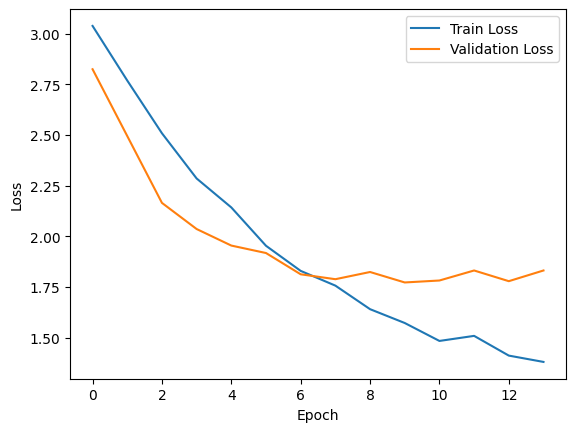

In [112]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [113]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=16
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6050 - loss: 1.5815
Test Loss: 1.5814992189407349
Test Accuracy: 0.6050000190734863


In [114]:
y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [116]:
class_names = [str(name) for name in class_names]

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.38      0.86      0.52         7
           2       0.00      0.00      0.00         3
           3       0.50      0.33      0.40         3
           4       0.36      0.40      0.38        10
           5       0.50      0.10      0.17        10
           6       0.84      0.85      0.84        66
           7       0.29      0.33      0.31        12
           8       0.88      0.70      0.78        10
           9       0.70      0.58      0.64        12
          10       0.91      0.83      0.87        12
          11       0.90      0.82      0.86        11
          12       0.00      0.00      0.00         3
          13       0.00      0.00      0.00         3
          14       0.33      0.30      0.32        10
          15       0.00      0.00      0.00         3
          16       0.71      1.00      0.83        10
          17       0.00    

draw the confusion_matrix

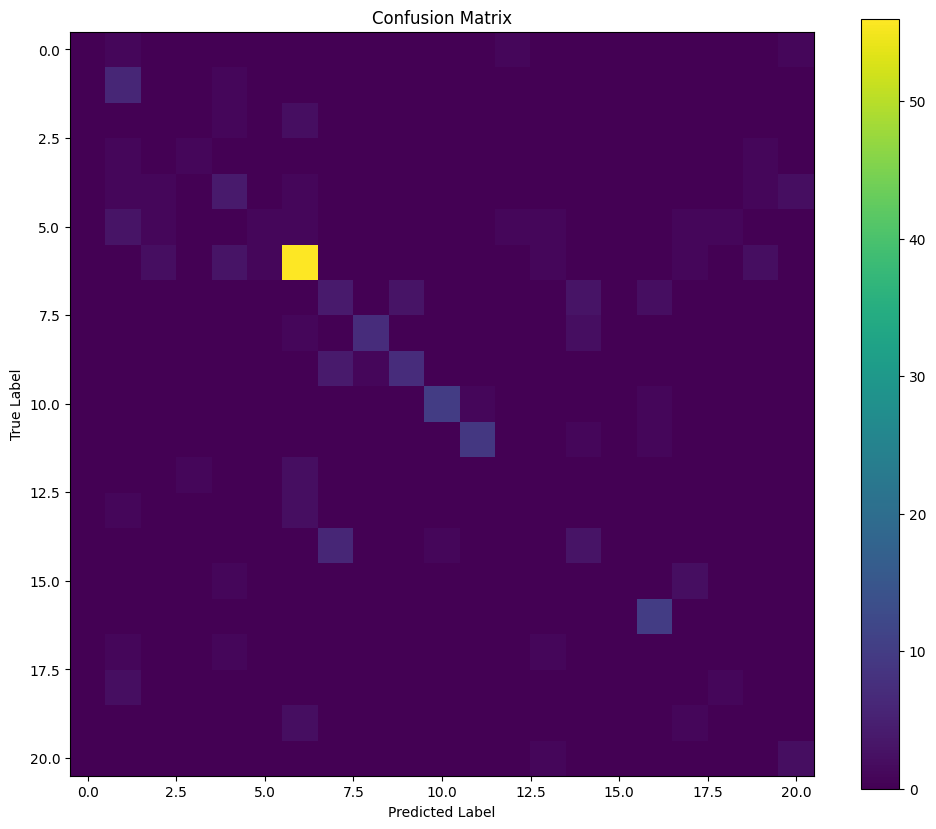

In [117]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [119]:
label_path = os.path.join(base_path, "lable.txt")

with open(label_path, "r") as f:
    class_names = [line.strip() for line in f.readlines()]

print(class_names)

['Vandalism 0', 'Stealing 1', 'Shoplifting 2', 'Shooting 3', 'Robbery 4', 'Roadaccidents 5', 'Normal 6', 'Walking 7', 'Walking_While_Using_Phone 8', 'Walking_While_Reading_Book 9', 'Standing_Still 10', 'Sitting 11', 'Fighting 12', 'Explosion 13', 'Meet_and_Split 14', 'Burglary 15', 'Clapping 16', 'Assault 17', 'Arson 18', 'Arrest 19', 'Abuse 20']


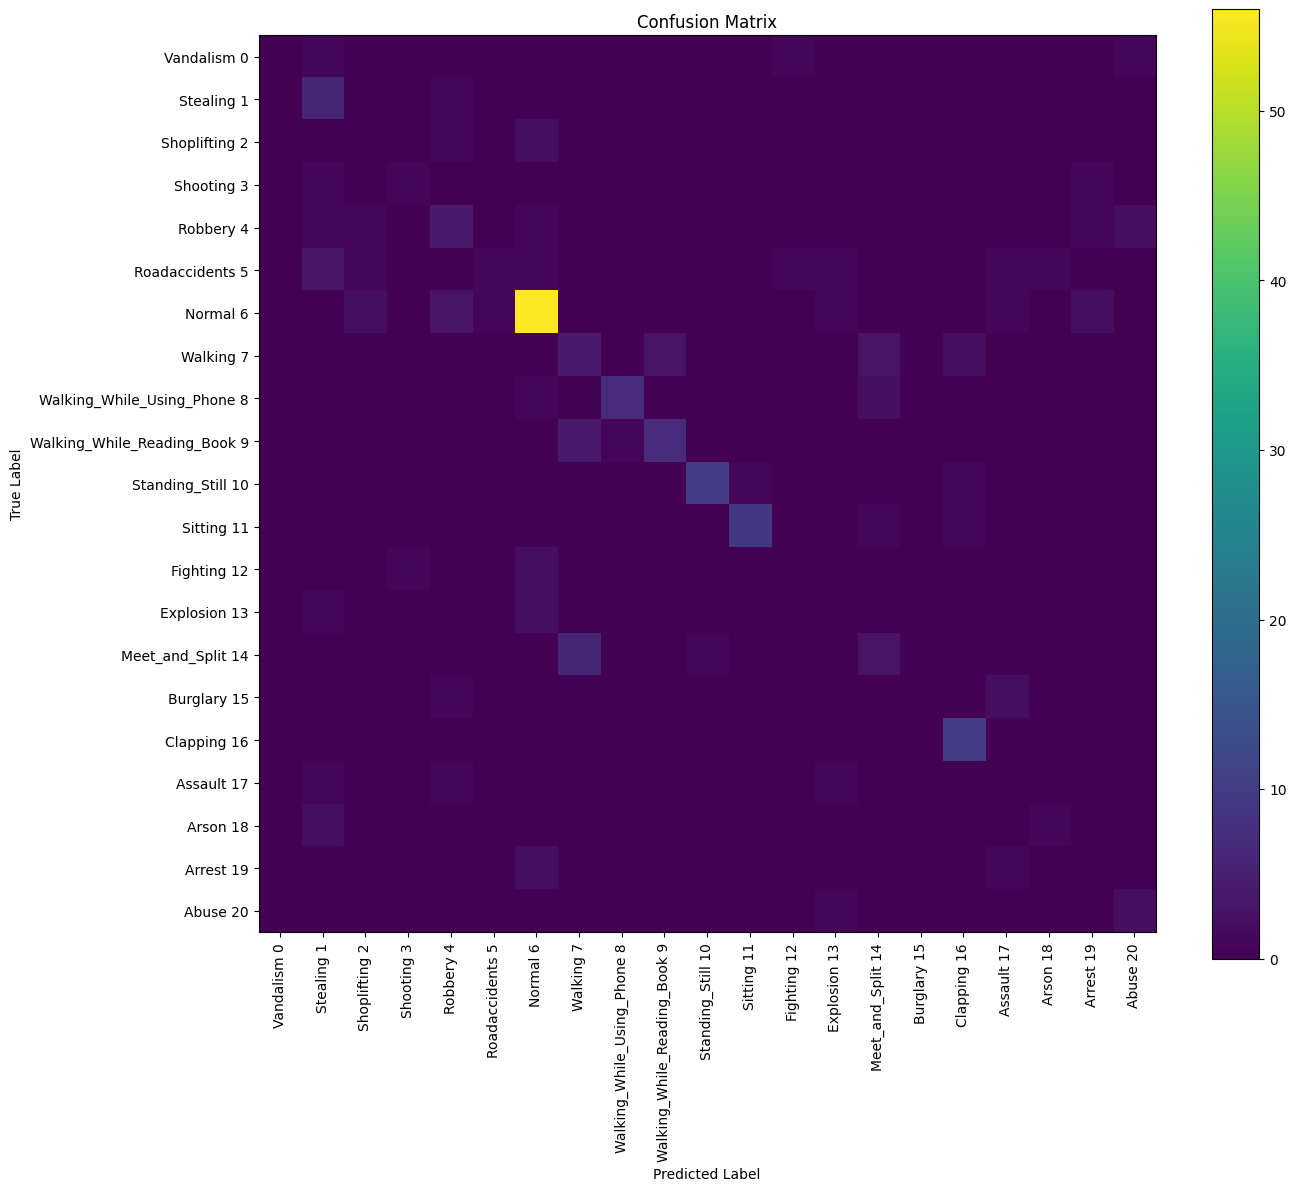

In [120]:
plt.figure(figsize=(14, 12))

plt.imshow(cm)
plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

---
# **STEP 6 - IMPROVE THE MODEL**

---

In [127]:
model = models.Sequential([
    layers.Input(shape=(16, 1280)),

    layers.Bidirectional(
        layers.LSTM(128, return_sequences=True)
    ),

    layers.Dropout(0.4),

    layers.Bidirectional(
        layers.LSTM(64)
    ),

    layers.Dropout(0.4),

    layers.Dense(64, activation="relu"),

    layers.Dense(21, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 16, 256)        │     1,442,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 21)             │         1,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,616,789 (6.17 MB)

 Trainable params: 1,616,789 (6.17 MB)

 Non-trainable params: 0 (0.00 B)

In [128]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=30,
    batch_size=16,
    callbacks=[early_stopping]
)

Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.2021 - loss: 2.7098 - val_accuracy: 0.2680 - val_loss: 2.3174
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3319 - loss: 2.1840 - val_accuracy: 0.3711 - val_loss: 2.0101
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3926 - loss: 1.8998 - val_accuracy: 0.3608 - val_loss: 2.0186
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4330 - loss: 1.7596 - val_accuracy: 0.4278 - val_loss: 1.9284
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4872 - loss: 1.6058 - val_accuracy: 0.4485 - val_loss: 1.8500
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4968 - loss: 1.5302 - val_accuracy: 0.4381 - val_loss: 1.8911
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5340 - loss: 1.4347 - val_accuracy: 0.4536 - val_loss: 1.8495
Epoch 8/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5755 - loss: 1.3122 - val_accuracy: 0.4742 - v

In [129]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=16
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4900 - loss: 1.8443
Test Loss: 1.844303846359253
Test Accuracy: 0.49000000953674316
